<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## Table of Contents:

- [Imports](#imports)
- [1 - Data Importing and Exploration](#1---data-importing-and-exploration)
    - 1a) Importing
    - 1b) Data Set Dimensions
    - 1c) Unique Dates Present
    - 1d) Missing Values
    - 1e) Input Feature Data Types
    - 1f) Find the Error in the README File
    - 1g) Descriptive Statistics
    - 1h) Visualizations
- [2 - Data Preparation](#2---data-preparation)
    - 2a) Remove the Descriptive Features
    - 2b) Correlations
    - 2c) Data Partitioning
    - 2d) Encoding Categorical Features
- [3 - Initial Model Training](#3---initial-model-training)
    - 3a) Create Models
    - 3b) Observe Model Metrics
    - 3c) Discussion
- [4 - Tuning Model Hyperparameters](#4---tuning-model-hyperparameters)
    - 4a) Optimize Lasso
    - 4b) Optimize Decision Tree Regressor
    - 4c) Optimize Random Forest Regressor
- [5 - Model Selection](#5---model-selection)
    - 5a) Best Model
    - 5b) Best Model Predictions
    - 5c) Discussion
- [6 - Feature Importance](#6---feature-importance)
    - 6a) Best Model Feature Importance
    - 6b) Discussion

</div>

##### **IMPORTANT**

Hyperlinks likely still do not work, please use dropdowns if it helps navigability

---

##### **ORIENTATION**

- This follows COMP4432's week 7-8 assignment

---

##### **SUMMARY**

In-Progress

<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## Imports

- [Back to Table of Contents](#table-of-contents)

</div>

In [1]:
# Arrays and matricies
import numpy as np

# Databasing
import pandas as pd

# Visualizations
import matplotlib.pyplot as plt
import seaborn as sns

# Data splitting and CV
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV

# Machine Learning Models
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Metrics
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, confusion_matrix, classification_report, roc_auc_score

# Encoders/Scalers/Transformers
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Ignore warnings because no...
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## 1 - Data Importing and Exploration

- [Back to Table of Contents](#table-of-contents)

</div>

#### 1a) Importing

In [2]:
# Read the csv URL into a pandas dataframe
df = pd.read_csv("https://raw.githubusercontent.com/arjayit/cs4432_data/master/bike_share_hour.csv")
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


---

#### 1b) Data Set Dimensions

In [3]:
# Shape of the dataset
print(f'\033[35mRows:\033[0m {df.shape[0]}\n'
      f'\033[35mCols:\033[0m {df.shape[1]}')

Rows: 17379
Cols: 17


---

#### 1c) Unique Dates Present

##### 1ci)

In [4]:
# Present the number of unique dates from the 'dteday' col
print(f'\033[35mUnique Dates: \033[0m{df['dteday'].nunique()}')

Unique Dates: 731


##### 1cii)

The dataset ranges all of 2011 and 2012 which totals 730 days, seeing that there are 731 unique dates and assuming that data is inputted per day, this likely means that there is at least one row that is not a proper date and will need to be handled.  Furthermore, this can indicate that more than just one row may be faulty since if one row was inputted incorrectly, there could be more inputted incorrectly.

---

#### 1d) Missing Values

##### 1di)

In [5]:
# Identify nulls in each column
# Note that this will not catch INCORRECTLY INPUTED DATA if any exist
df.isnull().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

##### 1dii)

In [6]:
# Expected rows assuming data is recorded hourly using 731 unique days from 1ci
print(f'\033[35mExpected Rows: \033[0m\t\t{731 * 24}')
print(f'\033[35mTotal Acutal Rows: \033[0m\t{df.shape[0]}')

Expected Rows: 		17544
Total Acutal Rows: 	17379


##### 1diii)

Assuming that the data was logged on an hourly basis, there should only be 17,520 rows, but the dataset has 17,379 rows which is 141 rows short of the actual hours in 2 years and 162 rows short assuming that 731 unique days is accurate.  This indicates that multiple rows may be duplicates, incorrectly inputted data, or perhaps dummy data.  This will need to be identified and handled accordingly.

##### 1div)

In [7]:
# Check each day for how many entries they have, then get the counts of these days
df.groupby('dteday').size().value_counts()

24    655
23     62
22      6
18      2
12      1
16      1
8       1
17      1
1       1
11      1
Name: count, dtype: int64

In [8]:
# See if the missing hours add up to the amount of missing rows (162)
print(f'\033[35mTotal Missing Hours: \033[0m{(24 - df.groupby('dteday').size()).sum()}')

Total Missing Hours: 165


##### 1dv)

In [9]:
# Calculate the percentage of distribution of days with x logged hours
df.groupby('dteday').size().value_counts(normalize=True).round(3) * 100

24    89.6
23     8.5
22     0.8
18     0.3
12     0.1
16     0.1
8      0.1
17     0.1
1      0.1
11     0.1
Name: proportion, dtype: float64

---

#### 1e) Input Feature Data Types

In [10]:
# Observe the dtypes of every column in the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  str    
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), str(1)
memory usage: 2.3 MB


In [11]:
# By the dataset's documentation, assign the respective cols to categorical/numerical
# 'cnt' is target
# 'casual' and 'registered' are target leakage cols
# 'instant' is an index
# 'dteday' are dates
cat_cols = [
    'season',
    'yr',
    'mnth',
    'hr',
    'holiday',
    'weekday',
    'workingday',
    'weathersit'
]
num_cols = [
    'cnt',
    'temp',
    'atemp',
    'hum',
    'windspeed'
]

---

#### 1f) Find the Error in the README File

##### 1fi)

In [12]:
# Observe month and season associations
# 1-4 seasons are resepectfully spring-winter
df.groupby('mnth')['season'].value_counts()

mnth  season
1     1         1429
2     1         1341
3     1          949
      2          524
4     2         1437
5     2         1488
6     2          960
      3          480
7     3         1488
8     3         1475
9     3         1053
      4          384
10    4         1451
11    4         1437
12    4          960
      1          523
Name: count, dtype: int64

##### 1fii)

By the README of the dataset, the 'mnth' and 'season' features are exactly as they sound; However, the relation between the two appear to be confusing in that most people group each season as 3 months (i.e. Summer is typically June, July, August).  It is likely that this dataset is grouping seasons by their days as opposed to the month of the year.

---

#### 1g) Descriptive Statistics

##### 1gi)

In [13]:
# Describe the numerical features including the target
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
cnt,17379.0,189.463088,181.387599,1.00,40.0000,142.0000,281.0000,977.0000
temp,17379.0,0.496987,0.192556,0.02,0.3400,0.5000,0.6600,1.0000
atemp,17379.0,0.475775,0.171850,0.00,0.3333,0.4848,0.6212,1.0000
hum,17379.0,0.627229,0.192930,0.00,0.4800,0.6300,0.7800,1.0000
windspeed,17379.0,0.190098,0.122340,0.00,0.1045,0.1940,0.2537,0.8507


##### 1gii)

Note that the ranges of 'temp', 'atemp', 'hum', 'windspeed' are generally [0,1] and by the README, they are divided by their respective maxes meaning that these numerical features are already normalized.  The range of the target feature as [1,977] match the case where a day only had 1 hour logged.

---

#### 1h) Visualizations

#### 1hi)

<Axes: title={'center': 'cnt vs. season'}, xlabel='season', ylabel='cnt'>

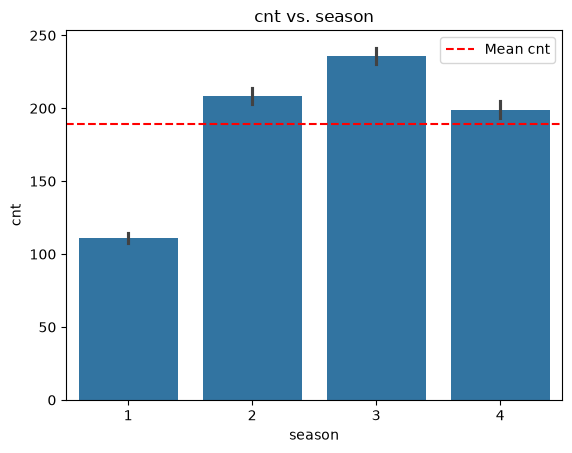

In [14]:
# Bar plot of 'cnt' vs 'season'
plt.title('cnt vs. season')
plt.axhline(y=df['cnt'].mean(), color='red', linestyle='--', label='Mean cnt')
sns.barplot(data=df, x='season', y='cnt')

- The mean of 'cnt' likely is more meaningful than the mean since we are more concerned with how many people used a bike in a given season.
- The graph does not match what I would assume where generally I would imagine these bars shifted one season to the left where the winter season is the least amount of bike usage.

##### 1hii)

<Axes: title={'center': 'cnt vs. workingday'}, xlabel='workingday', ylabel='cnt'>

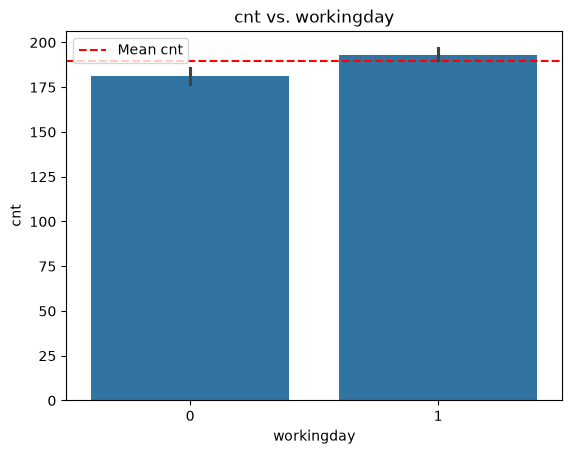

In [15]:
# Bar plot of 'cnt' vs. 'workingday'
plt.title('cnt vs. workingday')
plt.axhline(y=df['cnt'].mean(), color='red', linestyle='--', label='Mean cnt')
sns.barplot(data=df, x='workingday', y='cnt')

- The sum of 'cnt' likely is more helpful than the mean since we are relating it to a binary classifier (i.e. Is it or is it not a working day)
- Interestingly, there are more people that used bikes on work days as opposed to not.  Alternatively, this may make sense given that in Washington D.C., it may be more financially reasonable to use a bike for an individual to go into work as opposed to non-workdays where individuals are likely with family or friends and using a bike makes less sense.

##### 1hiii)

<Axes: title={'center': 'cnt vs. mnth'}, xlabel='mnth', ylabel='cnt'>

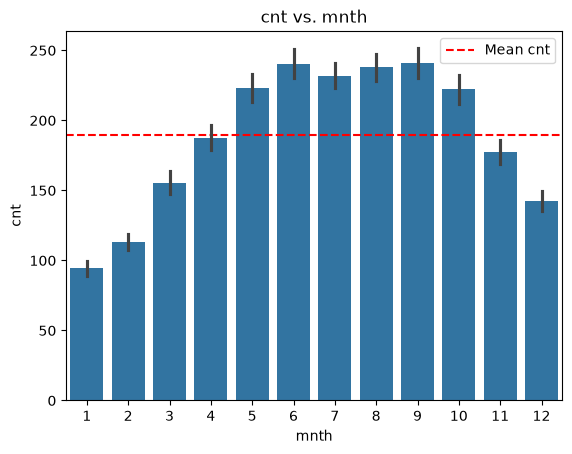

In [16]:
# Bar plot of 'cnt' vs. 'mnth'
plt.title('cnt vs. mnth')
plt.axhline(y=df['cnt'].mean(), color='red', linestyle='--', label='Mean cnt')
sns.barplot(data=df, x='mnth', y='cnt')

- The sum of 'cnt' is likely more meaningful than the mean as we can visually see a trend of bike usage that would generally agree with intuition
- As mentioned above, this visualization generally agrees with my intuition where the colder months have less usage as opposed to hotter months where the least usage is in the coldest month of the year in Washington D.C.

##### 1hiv)

<Axes: title={'center': 'cnt vs. weathersit'}, xlabel='weathersit', ylabel='cnt'>

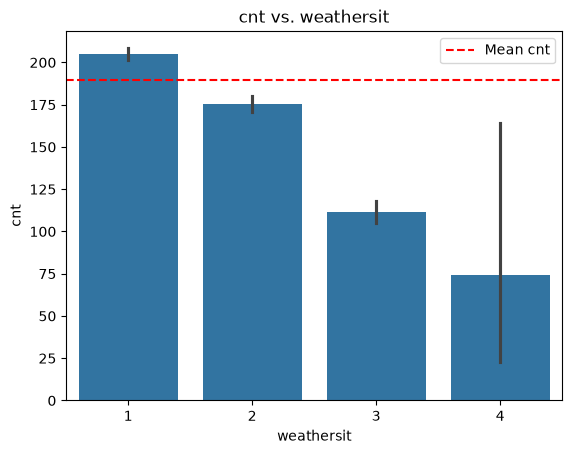

In [17]:
# Bar plot of 'cnt' vs. 'weathersit'
plt.title('cnt vs. weathersit')
plt.axhline(y=df['cnt'].mean(), color='red', linestyle='--', label='Mean cnt')
sns.barplot(data=df, x='weathersit', y='cnt')

- The sum of 'cnt' is likely more meaningful than the mean since this demonstrates a trendline where more bikes are used in optimal weather conditions as opposed to poor conditions like heavy rain
- As mentioned above, this visualization follows intuition where the worse the weather is for a given day, then the amount of bike users will decrease

##### 1hv)

<Axes: title={'center': 'cnt vs. weathersit by season'}, xlabel='weathersit', ylabel='cnt'>

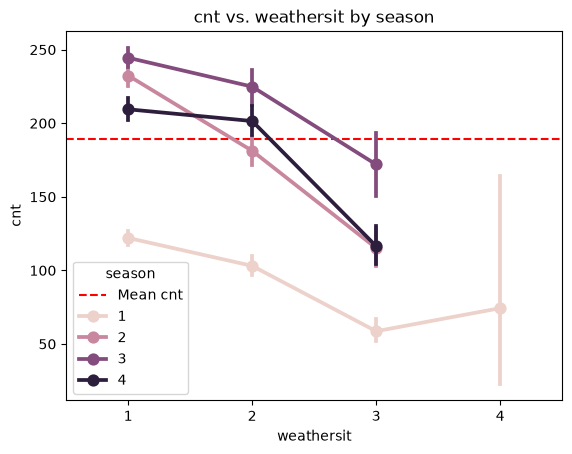

In [18]:
# Point plot of 'cnt' vs. 'weathersit' using 'season' as hue
plt.title('cnt vs. weathersit by season')
plt.axhline(y=df['cnt'].mean(), color='red', linestyle='--', label='Mean cnt')
sns.pointplot(data=df, x='weathersit', y='cnt', hue='season')

- The mean of 'cnt' might be more meaningful here since all respective means appear to be in unique locations and particularly the massive range of weathersit=4 and season=1 may cause minimal distinction of cnt.
- Following from the above, all trendlines and counts make intuitive sense where as weather becomes more inclimate, the less bike usage there is with the exception of spring and weathersit=4.  More exploration may be necessary to see if weathersit=4 in Spring is anomalous or perhaps there was a significant event during this timeframe that caused the influx of bike usage.  Otherwise, it may be incorrectly logged data.  Furthermore, the Spring season has a distinct lesser amount of bike usage which by my intuition doesn't make sense where I'd assume the Winter season would have the least.

##### 1hvi)

<Axes: title={'center': 'cnt vs. workingday=1'}, xlabel='hr', ylabel='cnt'>

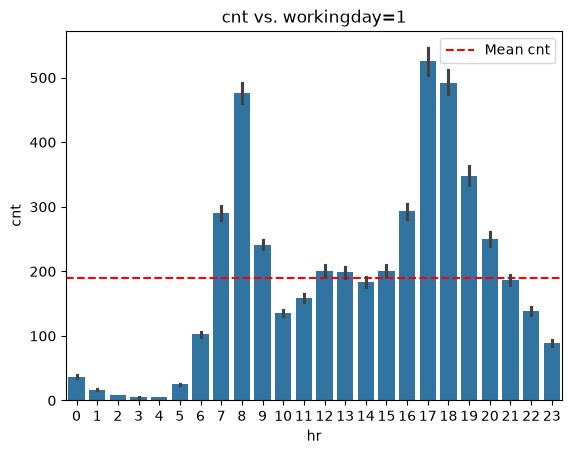

In [19]:
# Bar plot of 'cnt' vs. 'workingday'=1
plt.title('cnt vs. workingday=1')
plt.axhline(y=df['cnt'].mean(), color='red', linestyle='--', label='Mean cnt')
sns.barplot(data=df[df['workingday'] == 1], x='hr', y='cnt')

- The mean of 'cnt' may be more meaningful here since the peak times of bike usage are above the mean as opposed to less bike usage.
- Following from above, in a work-day, it makes intuitive sense that the large peak times of bike use are in the morning and evening time around usual times of commuting to and from work.  Additionally, the very few usage in midnight to 5 also makes intuitive sense.

##### 1hvii)

<Axes: title={'center': 'cnt vs. workingday=0'}, xlabel='hr', ylabel='cnt'>

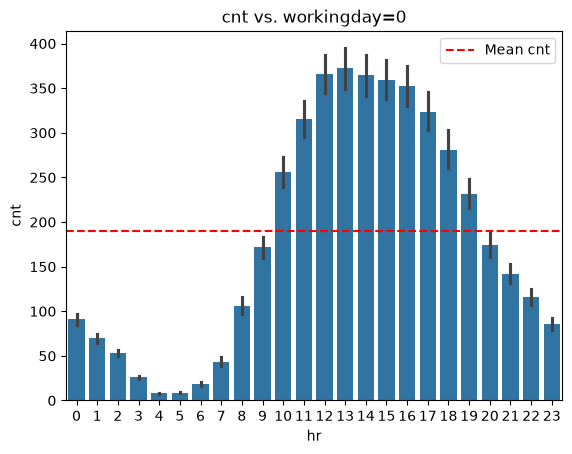

In [20]:
# Bar plot of 'cnt' vs. 'workingday'=0
plt.title('cnt vs. workingday=0')
plt.axhline(y=df['cnt'].mean(), color='red', linestyle='--', label='Mean cnt')
sns.barplot(data=df[df['workingday'] == 0], x='hr', y='cnt')

- Same as 1hvi, the mean is likely to be more meaningful than the sum of 'cnt'
- Intuitively for a non-work-day, this visualization makes sense where peak bike usage would be mid-day with ramping bike usage early morning and trailing bike usage past the evening time.  In contrast, this depicts bike usage more frequently throughout daytime as opposed to workdays having frequent bike usage during likely commute to work.

##### 1hviii)

<Axes: title={'center': 'cnt Distribution'}, xlabel='cnt', ylabel='Count'>

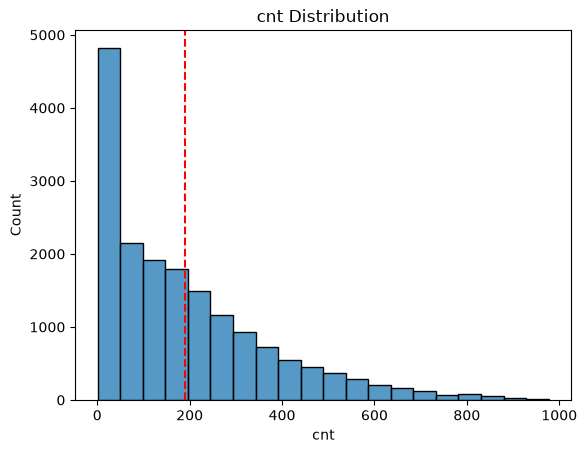

In [21]:
# Histogram of 'cnt'
plt.title('cnt Distribution')
plt.axvline(x=df['cnt'].mean(), color='red', linestyle='--', label='Mean cnt')
sns.histplot(data=df, x='cnt', bins=20)

- The mean generally appears to encapsulate the larger majority of the target variable and may be more meaningful than just the sum of cnt
- The distribution is positively skewed with the large portion of total bike usage in an hour being within 1-50 bikes used.

<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## 2 - Data Preparation

- [Back to Table of Contents](#table-of-contents)

</div>

#### 2a) Remove the Descriptive Features

In [22]:
# Drop descriptive features
df = df.drop(columns=['dteday', 'instant'])

---

#### 2b) Correrlations

##### 2bi)

In [23]:
# Observe correlations between features
df.corr().round(2)

,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
season,1.00,-0.01,0.83,-0.01,-0.01,-0.00,0.01,-0.01,0.31,0.32,0.15,-0.15,0.12,0.17,0.18
yr,-0.01,1.00,-0.01,-0.00,0.01,-0.00,-0.00,-0.02,0.04,0.04,-0.08,-0.01,0.14,0.25,0.25
mnth,0.83,-0.01,1.00,-0.01,0.02,0.01,-0.00,0.01,0.20,0.21,0.16,-0.14,0.07,0.12,0.12
hr,-0.01,-0.00,-0.01,1.00,0.00,-0.00,0.00,-0.02,0.14,0.13,-0.28,0.14,0.30,0.37,0.39
holiday,-0.01,0.01,0.02,0.00,1.00,-0.10,-0.25,-0.02,-0.03,-0.03,-0.01,0.00,0.03,-0.05,-0.03
weekday,-0.00,-0.00,0.01,-0.00,-0.10,1.00,0.04,0.00,-0.00,-0.01,-0.04,0.01,0.03,0.02,0.03
workingday,0.01,-0.00,-0.00,0.00,-0.25,0.04,1.00,0.04,0.06,0.05,0.02,-0.01,-0.30,0.13,0.03
weathersit,-0.01,-0.02,0.01,-0.02,-0.02,0.00,0.04,1.00,-0.10,-0.11,0.42,0.03,-0.15,-0.12,-0.14
temp,0.31,0.04,0.20,0.14,-0.03,-0.00,0.06,-0.10,1.00,0.99,-0.07,-0.02,0.46,0.34,0.40
atemp,0.32,0.04,0.21,0.13,-0.03,-0.01,0.05,-0.11,0.99,1.00,-0.05,-0.06,0.45,0.33,0.40


##### 2bii)

Highly-Correlated Features (>0.67):
- season & mnth: 0.83
- temp & atemp: 0.99
- casual & cnt: 0.69
- registered & cnt: 0.97

##### 2biii)

In [24]:
# Remove 'casual', 'registered', and 'atemp'
# Recall that 'casual' & 'registered' are target leakage features
# Recall 'atemp' is feeling temperature which is close to the actual temperature (Nearly a duplicate in other words)
df = df.drop(columns=['casual', 'registered', 'atemp'])

---

#### 2c) Data Partitioning

In [25]:
# Create train/test sets at 67/33 split
# Note that stratify will not work with some instances of cnt being 1
X_train, X_test, y_train, y_test = train_test_split(df.drop(columns='cnt'),
                                                    df['cnt'],
                                                    test_size=0.33,
                                                    random_state=411)

---

#### 2d) Encoding Categorical Features

In [26]:
# Since numerical features already encoded, we only need to transform categoricals
# Use ColumnTransformer to transform categorical with OneHotEncoder
col_transform_onehot = ColumnTransformer(transformers=[
    ('cat_transform', OneHotEncoder(sparse_output=False, drop='first'), cat_cols)],
    remainder='passthrough',
    verbose_feature_names_out=False)

# Fit the data on the training dataset
col_transform_onehot.fit(X_train)

# Transform and rebuild the training dataset
X_train_onehot = col_transform_onehot.transform(X_train)
feature_names = col_transform_onehot.get_feature_names_out()
X_train_onehot = pd.DataFrame(X_train_onehot, columns=feature_names, index=X_train.index)

# Transform and rebuild the testing dataset
X_test_onehot = col_transform_onehot.transform(X_test)
feature_names = col_transform_onehot.get_feature_names_out()
X_test_onehot = pd.DataFrame(X_test_onehot, columns=feature_names, index=X_test.index)

In [27]:
# Ensure the transformed training dataset shape is 11643 x 52
X_train_onehot.shape == (11643, 52)

True

<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## 3 - Initial Model Training

- [Back to Table of Contents](#table-of-contents)

</div>

#### 3a) Create Models

##### 3ai-3aiv)

In [28]:
# Create the 4 algorithms
lr_onehot = LinearRegression()
lasso_onehot = Lasso()
dtr_onehot = DecisionTreeRegressor()
rfr_onehot = RandomForestRegressor()

---

#### 3b) Observe Model Metrics

##### 3bi-3biii)

In [45]:
# Function to simplify code for printing metrics
def print_model_metrics(estimator, args):
    # Cross-Validate and get results
    results = cross_validate(estimator=estimator, **args)

    # Print off R2, RMSE, MAE metrics
    print(f'\033[36mR2: \033[0m\t{results['test_r2'].mean().round(3)}\n'
        f'\033[36mRMSE: \033[0m\t{-results['test_rmse'].mean().round(3)}\n'
        f'\033[36mMAE: \033[0m\t{-results['test_mae'].mean().round(3)}\n')

In [46]:
# Define the 3 metrics for scoring
scoring = {
    'r2': 'r2',
    'rmse': 'neg_root_mean_squared_error',
    'mae': 'neg_mean_absolute_error'
}

# Define the args that are used across all 4 of the models
args = {
    'X': X_train_onehot,
    'y': y_train,
    'cv': 5,
    'scoring': scoring
}

In [47]:
# Run cross-validation and print respective metrics
print(f'\033[35m========== LINEAR REGRESSOR ==========\033[0m')
print_model_metrics(lr_onehot, args)

print(f'\033[35m========== LASSO REGRESSOR ===========\033[0m')
print_model_metrics(lasso_onehot, args)

print(f'\033[35m========== DECISION TREE REGRESSOR ===\033[0m')
print_model_metrics(dtr_onehot, args)

print(f'\033[35m========== RANDOM FOREST REGRESSOR ===\033[0m')
print_model_metrics(rfr_onehot, args)

========== LINEAR REGRESSOR ==========
R2: 	0.681
RMSE: 	102.19
MAE: 	75.589

========== LASSO REGRESSOR ===========
R2: 	0.645
RMSE: 	107.74
MAE: 	78.666

========== DECISION TREE REGRESSOR ===
R2: 	0.819
RMSE: 	76.787
MAE: 	46.822

========== RANDOM FOREST REGRESSOR ===
R2: 	0.905
RMSE: 	55.828
MAE: 	36.193



---

#### 3c) Discussion

- LINEAR REGRESSOR (3rd place)
    - 2nd worst performing in all 3 metrics
    - Model accounts for ~68.1% of 'cnt' variance
    - Prediction expected to be 75.6 away from the actual 'cnt'
- LASSO REGRESSOR (4th place)
    - Worst performing in all 3 metrics
    - Model accounts fro ~64.5% of 'cnt' variance
    - Prediction expected to be 78.7 away from the actual 'cnt'
- DECISION TREE REGRESSOR (2nd place)
    - 2nd best performing in all 3 metrics
    - Model accounts for ~81.9% of 'cnt' variance
    - Prediction expected to be 47.1 away from the actual 'cnt'
- RANDOM FOREST REGRESSOR (1st place)
    - Best performing in all 3 metrics
    - Model accounts for ~90.5% of 'cnt' variance
    - Prediction expected to be 36.2 away from the actual 'cnt'

<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## 4 - Tuning Model Hyperparameters

- [Back to Table of Contents](#table-of-contents)

</div>

#### 4a) Optimize Lasso

---

#### 4b) Optimize Decision Tree Regressor

---

#### 4c) Optimize Random Forest Regressor

<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## 5 - Model Selection

- [Back to Table of Contents](#table-of-contents)

</div>

#### 5a) Best Model

---

#### 5b) Best Model Predictions

---

#### 5c) Discussion

<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## 6 - Feature Importance

- [Back to Table of Contents](#table-of-contents)

</div>

#### 6a) Best Model Feature Importance

---

#### 6b) Discussion